# 21 · 이벤트 밀도 신호 구성 감사

**한 줄 답:** 19번에서 강하게 잡힌 `early_tracked_events >= 20` 신호를 더 쪼갠다. 목적은 이 신호가 실제 플레이 행동인지, 아니면 GA4 자동·세션·접속 이벤트가 많이 쌓인 착시인지 확인하는 것이다.

**이번 게이트 질문:** 첫 10분 이벤트 밀도는 어떤 이벤트들로 구성되어 있나?

**사전 판정 기준:**

- 고밀도 양성 집단에서 의도행동 카테고리 비중이 고밀도 음성보다 뚜렷하게 높으면 `early_tracked_events`는 플레이 의도 피처 후보로 유지한다.
- 고밀도 양성/음성 모두 GA4 자동·세션 또는 접속 이벤트가 대부분이면, 원 피처를 그대로 쓰지 않고 `early_deliberate_events`, `deliberate_share`, `event_diversity`로 정제한다.
- 셀 n이 한 자리수인 비교는 방향만 읽고 확정하지 않는다.

**금지선:** A/B 효과를 보지 않는다. 베타 표시 기기는 제외한다. 10분 이후 정보는 라벨/해석에만 쓰고 피처로 쓰지 않는다.

## 1. 실행한 SQL

아래 SQL은 `ml/sql/g5_event_density_event_composition.sql`에 저장되어 있다. 원시 `user_pseudo_id`는 쿼리 내부에서만 그룹화에 쓰고, 저장 결과에는 세그먼트와 집계값만 남긴다.

In [1]:
from pathlib import Path
import os, sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parents[1]
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'ml'))

from calm_ml import report as R

R.setup()
SQL_PATH = ROOT / 'ml/sql/g5_event_density_event_composition.sql'
OUT = ROOT / 'ml/reports/g5_event_density_composition_2026-09-15'
FIG = ROOT / 'ml/reports/figs'
OUT.mkdir(parents=True, exist_ok=True)

print(SQL_PATH.read_text(encoding='utf-8')[:2400] + '\n...')


-- G5 event-density composition audit, NOT a model and NOT an A/B read.
-- Question: does the strong early_tracked_events signal come from real play
-- actions, or from automatic/session/entry/connect event volume?
-- Cohort: GA4 devices whose first observed event in the full export history is
-- 2026-09-04..2026-09-11 KST, with a complete 24h label window available.
-- Exclude marked beta tester devices (ab_variant beta_A/beta_B).
-- Do not segment or draw conclusions by A/B arm.
-- Feature window: [first_ts, +10m). Label: [+10m, +24h).
-- Raw GA4 device IDs stay inside the query; output is aggregate only.
WITH actions AS (
  SELECT action_name, area FROM UNNEST([
    STRUCT('chop_tree' AS action_name, 'nature' AS area),
    ('first_chop', 'nature'),
    ('plant_seed', 'nature'),
    ('water_crop', 'nature'),
    ('harvest_crop', 'nature'),
    ('forage_pick', 'nature'),
    ('mine_ore', 'nature'),
    ('fishing_cast', 'fishing_sea'),
    ('fishing_catch', 'fishing_sea'),
    ('fishin

## 2. 데이터 로드와 기본 검산

In [2]:
events = pd.read_csv(OUT / 'event_composition.csv')
src = pd.read_csv(ROOT / 'ml/reports/g3_all_channel_later_targets_2026-09-15/all_channel_later_target_candidates.csv')

TRACKED_THRESHOLD = 20
DELIBERATE_THRESHOLD = 6

src['later_active'] = src.later_active.astype(bool)
src['tracked_high'] = src.early_tracked_events >= TRACKED_THRESHOLD
src['deliberate_high'] = src.early_actions >= DELIBERATE_THRESHOLD

def segment(row):
    if row.tracked_high and row.deliberate_high:
        return '고밀도+의도행동 많음'
    if row.tracked_high and not row.deliberate_high:
        return '고밀도+의도행동 적음'
    if not row.tracked_high and row.early_actions > 0:
        return '저밀도+의도행동 있음'
    return '저밀도+의도행동 없음'

src['split_segment'] = src.apply(segment, axis=1)
src['deliberate_share'] = np.where(src.early_tracked_events > 0, src.early_actions / src.early_tracked_events, 0)

group_check = src.groupby(['split_segment', 'later_active'], as_index=False).agg(
    devices=('device_label', 'size'),
    early_events=('early_tracked_events', 'sum'),
    deliberate_events=('early_actions', 'sum'),
    median_tracked=('early_tracked_events', 'median'),
    median_actions=('early_actions', 'median'),
    median_deliberate_share=('deliberate_share', 'median'),
)
group_check['deliberate_event_share'] = group_check.deliberate_events / group_check.early_events
group_check.to_csv(OUT / 'device_segment_density_profile.csv', index=False)
display(group_check)

assert len(src) == 95
assert int(src.later_active.sum()) == 12
assert events[['split_segment', 'later_active', 'event_category', 'event_name']].duplicated().sum() == 0


,split_segment,later_active,devices,early_events,deliberate_events,median_tracked,median_actions,median_deliberate_share,deliberate_event_share
0,고밀도+의도행동 많음,False,11,657,241,51.0,17.0,0.310345,0.366819
1,고밀도+의도행동 많음,True,7,1115,615,165.0,88.0,0.531469,0.551570
2,고밀도+의도행동 적음,False,8,235,21,26.0,3.0,0.101724,0.089362
3,고밀도+의도행동 적음,True,3,151,1,28.0,0.0,0.000000,0.006623
4,저밀도+의도행동 없음,False,62,488,0,6.0,0.0,0.000000,0.000000
5,저밀도+의도행동 없음,True,2,26,0,13.0,0.0,0.000000,0.000000
6,저밀도+의도행동 있음,False,2,38,2,19.0,1.0,0.052632,0.052632


## 3. 카테고리 구성

첫 10분 이벤트를 큰 카테고리로 접어서 본다. 막대 하나는 해당 세그먼트·라벨 집단의 전체 early event 100%다.

In [3]:
category = events.groupby(['split_segment', 'later_active', 'event_category'], as_index=False).agg(
    devices_in_group=('devices_in_group', 'max'),
    total_early_events_in_group=('total_early_events_in_group', 'max'),
    event_count=('event_count', 'sum'),
)
category['event_share'] = category.event_count / category.total_early_events_in_group
category.to_csv(OUT / 'category_composition.csv', index=False)
display(category.sort_values(['split_segment', 'later_active', 'event_share'], ascending=[True, False, False]).head(40))


,split_segment,later_active,event_category,devices_in_group,total_early_events_in_group,event_count,event_share
15,고밀도+의도행동 많음,True,의도행동:nature,7,1115,493,0.442152
11,고밀도+의도행동 많음,True,기타 추적,7,1115,431,0.386547
16,고밀도+의도행동 많음,True,의도행동:quest_social,7,1115,60,0.053812
12,고밀도+의도행동 많음,True,의도행동:advanced,7,1115,43,0.038565
10,고밀도+의도행동 많음,True,GA4 자동·세션,7,1115,41,0.036771
17,고밀도+의도행동 많음,True,진입·로그인·튜토리얼,7,1115,21,0.018834
13,고밀도+의도행동 많음,True,의도행동:craft_home,7,1115,12,0.010762
14,고밀도+의도행동 많음,True,의도행동:fishing_sea,7,1115,7,0.006278
18,고밀도+의도행동 많음,True,토스 연결 성공,7,1115,4,0.003587
19,고밀도+의도행동 많음,True,토스 연결 실패,7,1115,3,0.002691


g5_event_density_composition_categories.png  1525x828px


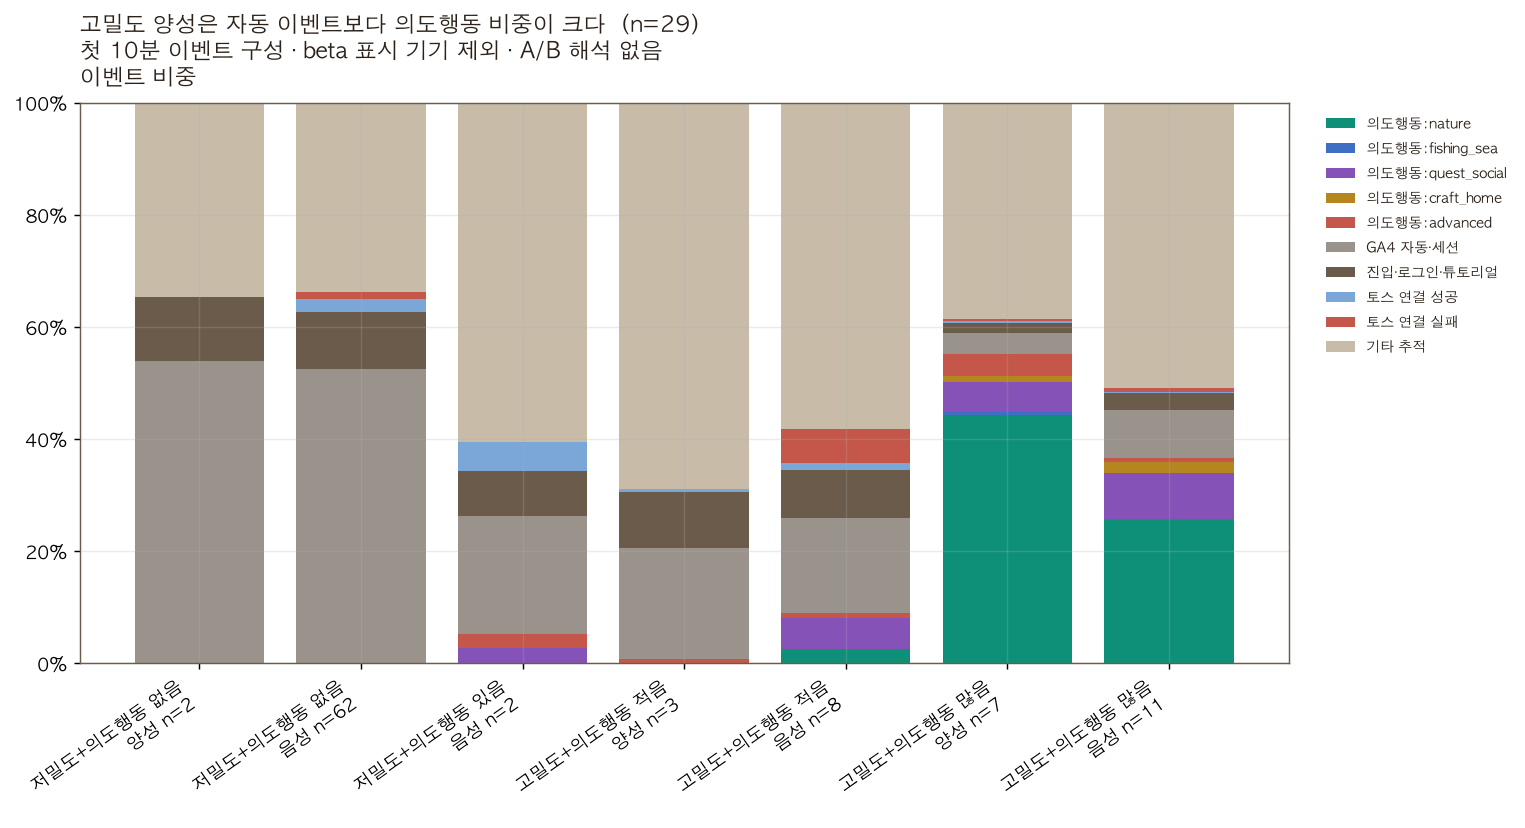

In [4]:
plot = category.copy()
plot['group'] = plot.apply(lambda r: f"{r.split_segment}\n{'양성' if r.later_active else '음성'} n={int(r.devices_in_group)}", axis=1)
group_order = (
    plot[['split_segment', 'later_active', 'group', 'devices_in_group']]
    .drop_duplicates()
    .assign(seg_order=lambda x: x.split_segment.map({
        '저밀도+의도행동 없음': 1,
        '저밀도+의도행동 있음': 2,
        '고밀도+의도행동 적음': 3,
        '고밀도+의도행동 많음': 4,
    }))
    .sort_values(['seg_order', 'later_active'], ascending=[True, False])
)
categories = [
    '의도행동:nature',
    '의도행동:fishing_sea',
    '의도행동:quest_social',
    '의도행동:craft_home',
    '의도행동:advanced',
    'GA4 자동·세션',
    '진입·로그인·튜토리얼',
    '토스 연결 성공',
    '토스 연결 실패',
    '기타 추적',
]
colors = {
    '의도행동:nature': R.PALETTE[2],
    '의도행동:fishing_sea': R.PALETTE[1],
    '의도행동:quest_social': R.PALETTE[4],
    '의도행동:craft_home': R.PALETTE[3],
    '의도행동:advanced': R.PALETTE[0],
    'GA4 자동·세션': '#9A938B',
    '진입·로그인·튜토리얼': '#6B5B4A',
    '토스 연결 성공': '#7AA6D8',
    '토스 연결 실패': '#C4574A',
    '기타 추적': '#C8BCA8',
}
pivot = (
    plot.pivot_table(index='group', columns='event_category', values='event_share', aggfunc='sum', fill_value=0)
    .reindex(group_order.group)
)
fig, ax = R.new(
    '고밀도 양성은 자동 이벤트보다 의도행동 비중이 크다',
    int(src.tracked_high.sum()),
    sub='첫 10분 이벤트 구성 · beta 표시 기기 제외 · A/B 해석 없음',
    ylab='이벤트 비중',
    figsize=(12, 5.6),
)
bottom = np.zeros(len(pivot))
for cat in categories:
    if cat not in pivot.columns:
        continue
    vals = pivot[cat].values
    ax.bar(np.arange(len(pivot)), vals, bottom=bottom, label=cat, color=colors[cat])
    bottom += vals
ax.set_xticks(np.arange(len(pivot)), pivot.index, rotation=35, ha='right')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
chart_category = R.save(fig, ax, 'g5_event_density_composition_categories', zero_base=False)
print(R.check(chart_category))
display(R.show(chart_category))


## 4. 고밀도 집단 안에서 양성과 음성 비교

이제 `tracked>=20`만 남기고, 양성 집단과 음성 집단의 상위 이벤트를 비교한다. 작은 n이라 순위 확정은 금물이고, 어떤 신호가 섞였는지 보는 감사용이다.

In [5]:
high_events = events[events.split_segment.str.startswith('고밀도')].copy()
high_totals = high_events.groupby('later_active', as_index=False).agg(
    devices=('devices_in_group', 'max'),
    total_events=('total_early_events_in_group', 'sum'),
)
top_events = (
    high_events.groupby(['later_active', 'event_name', 'event_category'], as_index=False)
    .agg(event_count=('event_count', 'sum'), devices_with_event=('devices_with_event', 'sum'))
)
denom = top_events.groupby('later_active').event_count.transform('sum')
top_events['event_share'] = top_events.event_count / denom
top_events = top_events.sort_values(['later_active', 'event_count'], ascending=[False, False])
top_events.to_csv(OUT / 'high_density_top_events.csv', index=False)
display(top_events.groupby('later_active').head(15))


,later_active,event_name,event_category,event_count,devices_with_event,event_share
77,True,chop_tree,의도행동:nature,272,6,0.214850
116,True,mine_ore,의도행동:nature,92,4,0.072670
82,True,dex_discover,기타 추적,77,9,0.060821
143,True,session_summary,기타 추적,58,5,0.045814
157,True,zone_enter,기타 추적,42,7,0.033175
100,True,forage_pick,의도행동:nature,38,5,0.030016
153,True,tutorial_step,기타 추적,38,7,0.030016
84,True,econ_tx,기타 추적,37,9,0.029226
132,True,npc_talk,의도행동:quest_social,37,6,0.029226
135,True,plant_seed,의도행동:nature,36,6,0.028436


g5_event_density_composition_high_top_events.png  1142x771px


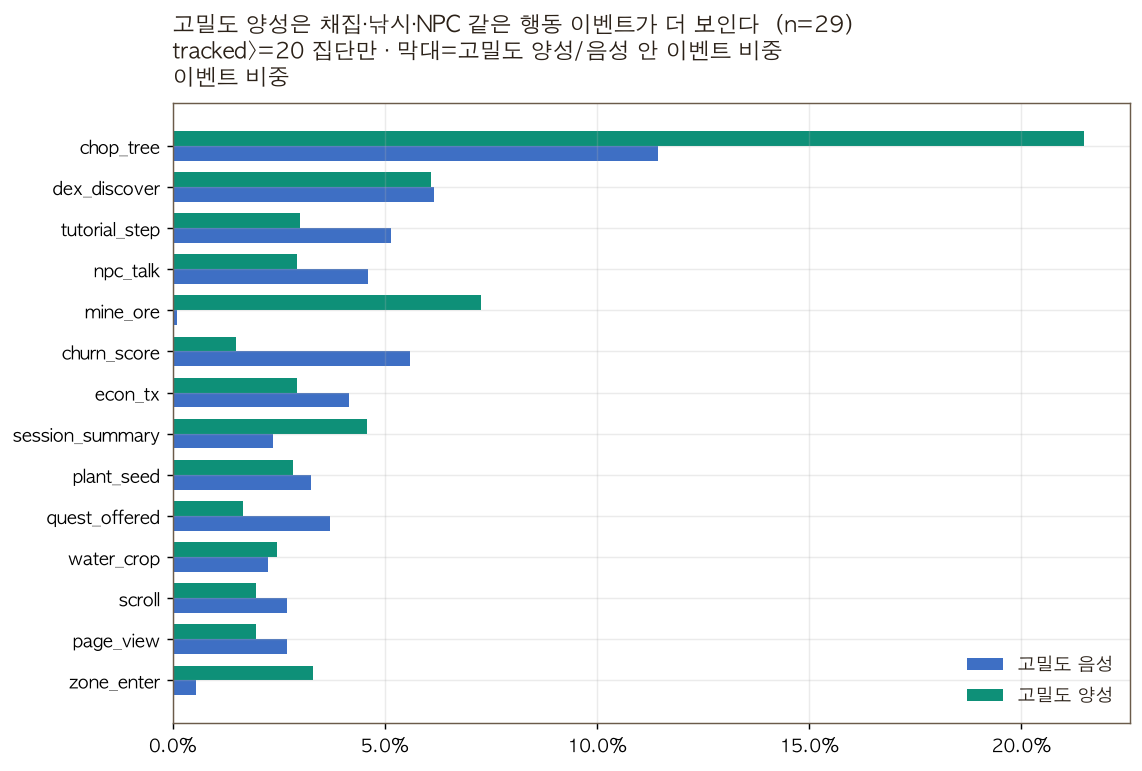

In [6]:
top_names = (
    top_events.groupby('event_name', as_index=False).event_count.sum()
    .sort_values('event_count', ascending=False)
    .head(14)
    .event_name
)
plot_top = top_events[top_events.event_name.isin(top_names)].copy()
pivot_top = plot_top.pivot_table(index='event_name', columns='later_active', values='event_share', aggfunc='sum', fill_value=0)
pivot_top = pivot_top.assign(total=pivot_top.sum(axis=1)).sort_values('total').drop(columns='total')
for col in [False, True]:
    if col not in pivot_top:
        pivot_top[col] = 0

fig, ax = R.new(
    '고밀도 양성은 채집·낚시·NPC 같은 행동 이벤트가 더 보인다',
    int(src.tracked_high.sum()),
    sub='tracked>=20 집단만 · 막대=고밀도 양성/음성 안 이벤트 비중',
    ylab='이벤트 비중',
    figsize=(9.5, 6.2),
)
y = np.arange(len(pivot_top))
height = 0.36
ax.barh(y - height / 2, pivot_top[False], height, color=R.PALETTE[1], label='고밀도 음성')
ax.barh(y + height / 2, pivot_top[True], height, color=R.PALETTE[2], label='고밀도 양성')
ax.set_yticks(y, pivot_top.index)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.legend(frameon=False)
chart_top = R.save(fig, ax, 'g5_event_density_composition_high_top_events', zero_base=False)
print(R.check(chart_top))
display(R.show(chart_top))


## 5. 의도행동 비율 요약

모델 피처 관점에서는 단순 이벤트 수보다 `의도행동 / 전체 early event`가 더 견고할 수 있다. 이 값이 양성에서 실제로 갈리는지 본다.

In [7]:
share_summary = src.groupby(['split_segment', 'later_active'], as_index=False).agg(
    devices=('device_label', 'size'),
    median_tracked=('early_tracked_events', 'median'),
    median_actions=('early_actions', 'median'),
    median_deliberate_share=('deliberate_share', 'median'),
    mean_deliberate_share=('deliberate_share', 'mean'),
)
share_summary.to_csv(OUT / 'deliberate_share_summary.csv', index=False)
display(share_summary)


,split_segment,later_active,devices,median_tracked,median_actions,median_deliberate_share,mean_deliberate_share
0,고밀도+의도행동 많음,False,11,51.0,17.0,0.310345,0.329429
1,고밀도+의도행동 많음,True,7,165.0,88.0,0.531469,0.473337
2,고밀도+의도행동 적음,False,8,26.0,3.0,0.101724,0.087080
3,고밀도+의도행동 적음,True,3,28.0,0.0,0.000000,0.003236
4,저밀도+의도행동 없음,False,62,6.0,0.0,0.000000,0.000000
5,저밀도+의도행동 없음,True,2,13.0,0.0,0.000000,0.000000
6,저밀도+의도행동 있음,False,2,19.0,1.0,0.052632,0.052632


g5_event_density_composition_deliberate_share.png  1151x748px


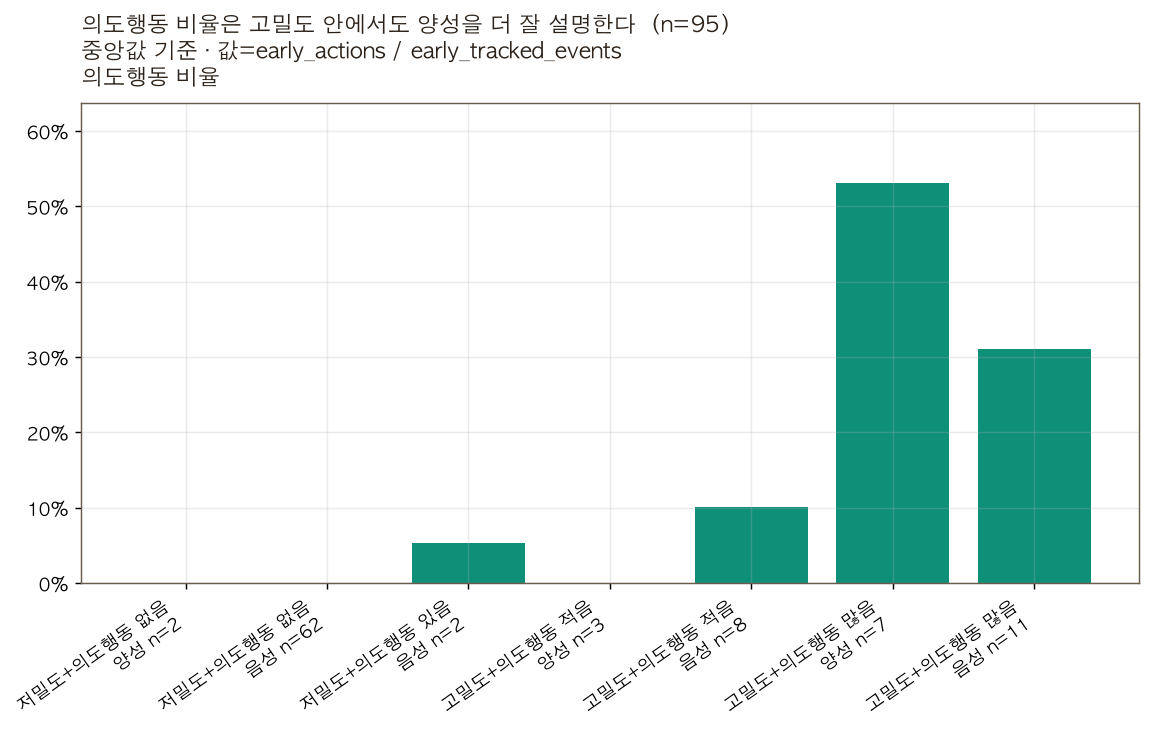

In [8]:
plot_share = share_summary.copy()
plot_share['label'] = plot_share.apply(lambda r: f"{r.split_segment}\n{'양성' if r.later_active else '음성'} n={int(r.devices)}", axis=1)
plot_share['order'] = plot_share.split_segment.map({
    '저밀도+의도행동 없음': 1,
    '저밀도+의도행동 있음': 2,
    '고밀도+의도행동 적음': 3,
    '고밀도+의도행동 많음': 4,
}) * 10 - plot_share.later_active.astype(int)
plot_share = plot_share.sort_values('order')

fig, ax = R.new(
    '의도행동 비율은 고밀도 안에서도 양성을 더 잘 설명한다',
    len(src),
    sub='중앙값 기준 · 값=early_actions / early_tracked_events',
    ylab='의도행동 비율',
    figsize=(10.5, 4.8),
)
ax.bar(np.arange(len(plot_share)), plot_share.median_deliberate_share, color=R.PALETTE[2])
ax.set_xticks(np.arange(len(plot_share)), plot_share.label, rotation=35, ha='right')
ax.set_ylim(0, max(0.55, plot_share.median_deliberate_share.max() * 1.2))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
chart_share = R.save(fig, ax, 'g5_event_density_composition_deliberate_share', zero_base=True)
print(R.check(chart_share))
display(R.show(chart_share))


## 6. 판정

`early_tracked_events`는 버릴 신호가 아니다. 다만 그대로 쓰면 자동·세션 이벤트와 실제 플레이 행동이 섞인다. 다음 피처 파이프라인에서는 `early_tracked_events`를 유지하되, 반드시 `early_actions`, `early_action_kinds`, `early_area_count`, `deliberate_share`, 자동/접속 이벤트 카운트를 함께 넣어 분리한다.

**이 숫자로 말할 수 없는 것:** 아직 95대, 양성 12대라 계수 안정성은 낮다. 특히 고밀도 세그먼트 안의 양성/음성 비교는 감사용이지 운영 규칙 확정용이 아니다. 또한 `session_time`, `econ_tx`, `daily_bonus` 같은 추적 이벤트는 이름만으로 자동/플레이를 완전히 구분하기 어렵다.

**다음에 확인할 것:** 고밀도+의도행동 적음 집단에서 10분 직후 첫 의도행동까지 걸린 시간과 첫 도달 영역을 본다. 이 집단이 “막혀 있다가 풀린 사람”인지 “켜두기/자동 이벤트만 많았던 사람”인지 갈라야 한다.